# Notebook 01 — Entrenamiento del Modelo LightGBM
## Predicción de Aprobación de Préstamos (Loan Approval)
### Inteligencia Artificial I — Actividad 3 | Grupo 10

**Integrantes:**
- Julian Camilo Cardenas Torres
- Jhon Alexander Vargas Catuche
- Juan Sebastian Vasquez Peña 

**Algoritmo:** LightGBM  
**Dataset:** Loan Approval Dataset — 4,269 registros, 11 features  
**Problema:** Clasificación binaria — Aprobado (1) / Rechazado (0)

---

## 1. Importación de Librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import lightgbm as lgb
import joblib
import warnings
import sys, os

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
sys.path.append('..')

# Estilos
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')

PALETTE    = ['#27ae60', '#e74c3c']   # Verde=Approved, Rojo=Rejected
SEED       = 42

print("Librerías cargadas ✓")
print(f"LightGBM versión: {lgb.__version__}")
print(f"Pandas  versión:  {pd.__version__}")

Librerías cargadas ✓
LightGBM versión: 4.6.0
Pandas  versión:  3.0.3


## 2. Carga y Exploración Inicial del Dataset

Se carga el dataset crudo (`data/raw/dataset.csv`) con **4,269 registros** y **11 features**
sobre préstamos bancarios. El target es `loan_status` (Approved / Rejected).

In [3]:
# Carga del dataset crudo
df_raw = pd.read_csv('../data/raw/loan_approval_dataset_RAW.csv')

print(f"{'='*50}")
print(f"  INFORMACIÓN DEL DATASET")
print(f"{'='*50}")
print(f"  Filas:    {df_raw.shape[0]:,}")
print(f"  Columnas: {df_raw.shape[1]}")
print()
df_raw.info()

  INFORMACIÓN DEL DATASET
  Filas:    4,269
  Columnas: 12

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   no_of_dependents          4269 non-null   int64
 1   education                 4269 non-null   str  
 2   self_employed             4269 non-null   str  
 3   income_annum              4269 non-null   int64
 4   loan_amount               4269 non-null   int64
 5   loan_term                 4269 non-null   int64
 6   cibil_score               4269 non-null   int64
 7   residential_assets_value  4269 non-null   int64
 8   commercial_assets_value   4269 non-null   int64
 9   luxury_assets_value       4269 non-null   int64
 10  bank_asset_value          4269 non-null   int64
 11  loan_status               4269 non-null   str  
dtypes: int64(9), str(3)
memory usage: 485.8 KB


In [4]:
# Estadísticas descriptivas
df_raw.describe(include='all').round(2)

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
count,4269.0,4269,4269,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269
unique,NaN,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,Graduate,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Approved
freq,NaN,2144,2150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2656
mean,2.5,NaN,NaN,5059123.92,15133450.46,10.90,599.94,7473272.43,4973155.31,15126305.93,4976692.43,NaN
std,1.7,NaN,NaN,2806839.83,9043362.98,5.71,172.43,6502877.68,4388966.09,9103753.67,3250185.31,NaN
min,0.0,NaN,NaN,200000.00,300000.00,2.00,300.00,0.00,0.00,300000.00,0.00,NaN
25%,1.0,NaN,NaN,2700000.00,7700000.00,6.00,453.00,2200000.00,1300000.00,7500000.00,2300000.00,NaN
50%,3.0,NaN,NaN,5100000.00,14500000.00,10.00,600.00,5600000.00,3700000.00,14600000.00,4600000.00,NaN
75%,4.0,NaN,NaN,7500000.00,21500000.00,16.00,748.00,11300000.00,7600000.00,21700000.00,7100000.00,NaN


In [5]:
# Primeras filas
df_raw.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


## 3. Análisis Exploratorio de Datos (EDA)

Se analizan distribuciones, relaciones entre features y el target, correlaciones y outliers.

### 3.1 Distribución del Target (loan_status)

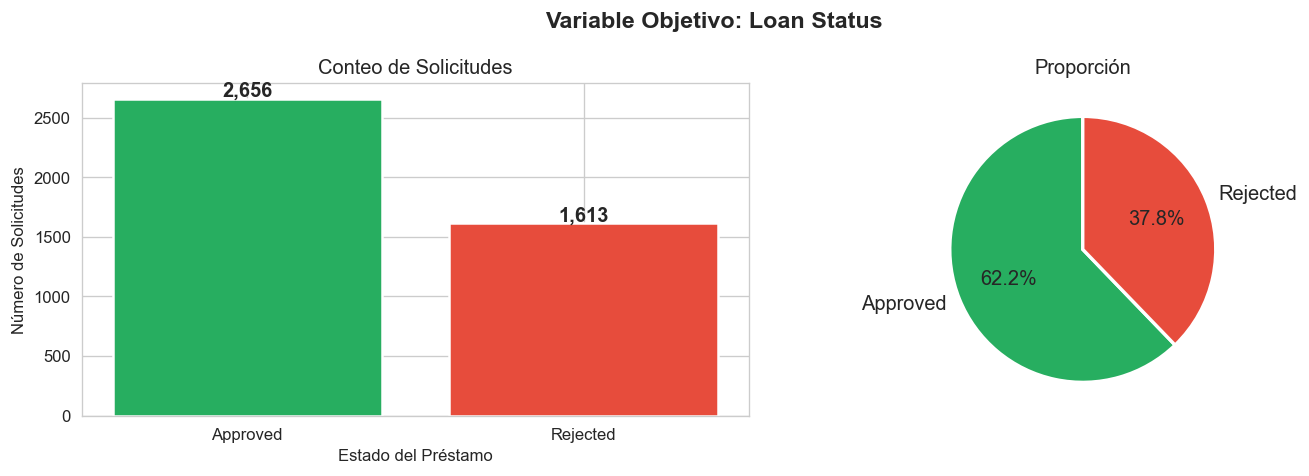

  Approved: 2,656 (62.2%)
  Rejected: 1,613 (37.8%)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Variable Objetivo: Loan Status', fontsize=14, fontweight='bold')

counts = df_raw['loan_status'].value_counts()
pcts   = df_raw['loan_status'].value_counts(normalize=True) * 100

# Barras
bars = axes[0].bar(counts.index, counts.values, color=PALETTE, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{val:,}', ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Conteo de Solicitudes', fontsize=12)
axes[0].set_ylabel('Número de Solicitudes')
axes[0].set_xlabel('Estado del Préstamo')

# Pie
axes[1].pie(counts.values, labels=['Approved', 'Rejected'], colors=PALETTE,
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporción', fontsize=12)

plt.tight_layout()
plt.savefig('../docs/eda_target.png', bbox_inches='tight')
plt.show()

print(f"  Approved: {counts['Approved']:,} ({pcts['Approved']:.1f}%)")
print(f"  Rejected: {counts['Rejected']:,} ({pcts['Rejected']:.1f}%)")

### 3.2 Distribución de Variables Numéricas por Estado del Préstamo

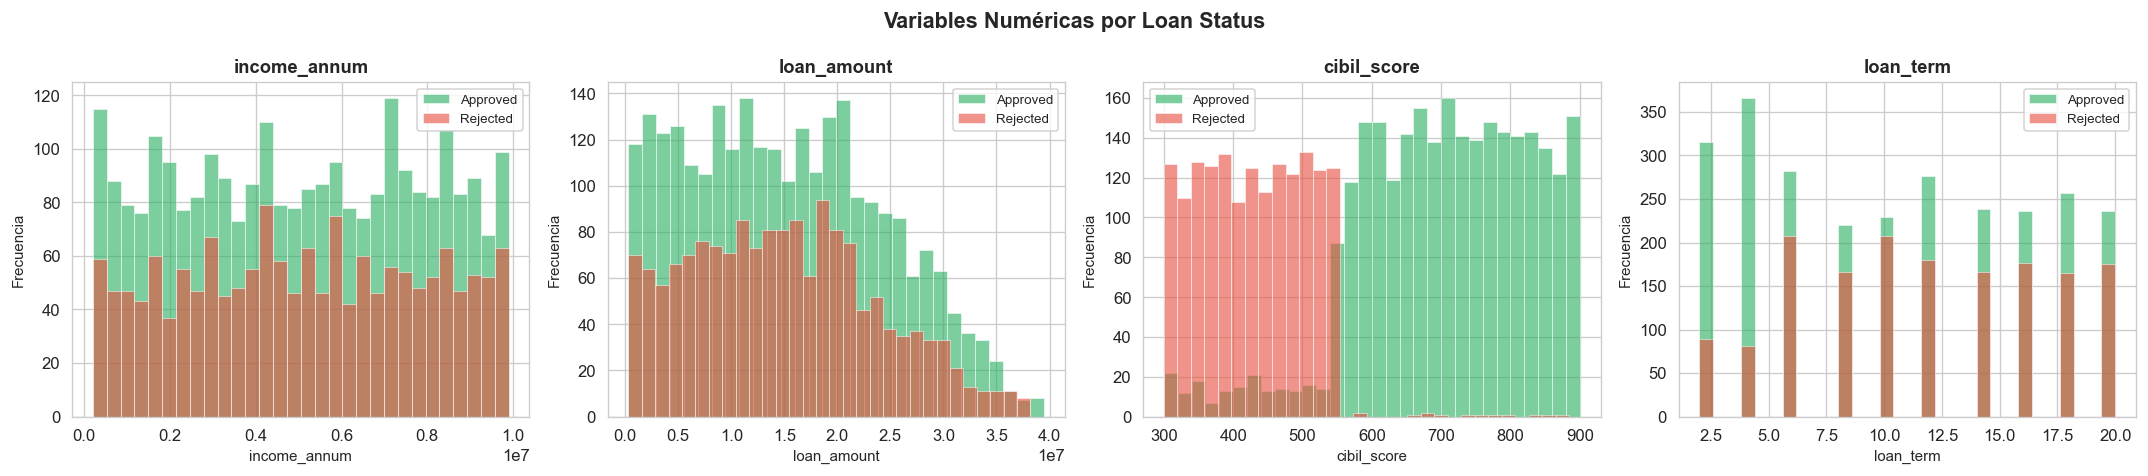

In [7]:
num_vars = ['income_annum', 'loan_amount', 'cibil_score', 'loan_term']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Variables Numéricas por Loan Status', fontsize=13, fontweight='bold')

for ax, var in zip(axes, num_vars):
    for status, color in zip(['Approved', 'Rejected'], PALETTE):
        subset = df_raw[df_raw['loan_status'] == status][var].dropna()
        ax.hist(subset, bins=30, alpha=0.6, color=color, label=status,
                edgecolor='white', linewidth=0.5)
    ax.set_title(var, fontsize=11, fontweight='bold')
    ax.set_xlabel(var, fontsize=9)
    ax.set_ylabel('Frecuencia', fontsize=9)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../docs/eda_numericas.png', bbox_inches='tight')
plt.show()

### 3.3 Tasa de Aprobación por Variables Categóricas

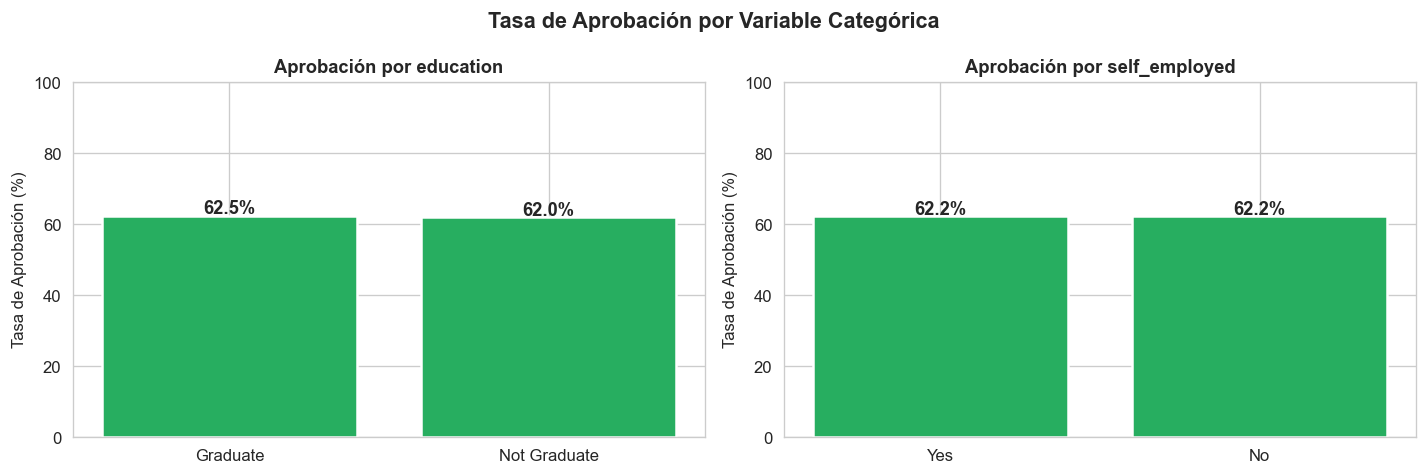

In [8]:
cat_vars = ['education', 'self_employed']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Tasa de Aprobación por Variable Categórica', fontsize=13, fontweight='bold')

for ax, var in zip(axes, cat_vars):
    approval_rate = df_raw.groupby(var)['loan_status'].apply(
        lambda x: (x == 'Approved').mean() * 100
    ).sort_values(ascending=False)

    bars = ax.bar(approval_rate.index.astype(str), approval_rate.values,
                  color=['#27ae60' if v >= 50 else '#e74c3c' for v in approval_rate.values],
                  edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, approval_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
    ax.set_title(f'Aprobación por {var}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Tasa de Aprobación (%)')
    ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('../docs/eda_categoricas.png', bbox_inches='tight')
plt.show()

### 3.4 Distribución del Score CIBIL (variable más importante)

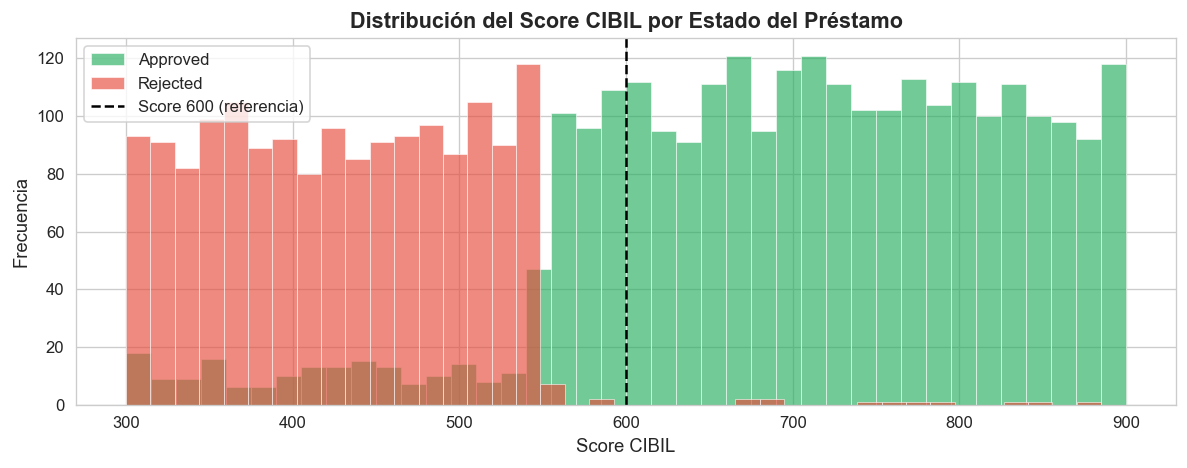

CIBIL promedio Approved: 703.5
CIBIL promedio Rejected: 429.5


In [9]:
fig, ax = plt.subplots(figsize=(10, 4))

for status, color in zip(['Approved', 'Rejected'], PALETTE):
    subset = df_raw[df_raw['loan_status'] == status]['cibil_score']
    ax.hist(subset, bins=40, alpha=0.65, color=color, label=status,
            edgecolor='white', linewidth=0.5)

ax.axvline(x=600, color='black', linestyle='--', linewidth=1.5, label='Score 600 (referencia)')
ax.set_title('Distribución del Score CIBIL por Estado del Préstamo', fontsize=13, fontweight='bold')
ax.set_xlabel('Score CIBIL', fontsize=11)
ax.set_ylabel('Frecuencia', fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../docs/eda_cibil.png', bbox_inches='tight')
plt.show()

print("CIBIL promedio Approved:", df_raw[df_raw['loan_status']=='Approved']['cibil_score'].mean().round(1))
print("CIBIL promedio Rejected:", df_raw[df_raw['loan_status']=='Rejected']['cibil_score'].mean().round(1))

### 3.5 Detección de Valores Nulos y Outliers

Valores nulos por columna:
  Ningún valor nulo encontrado ✓


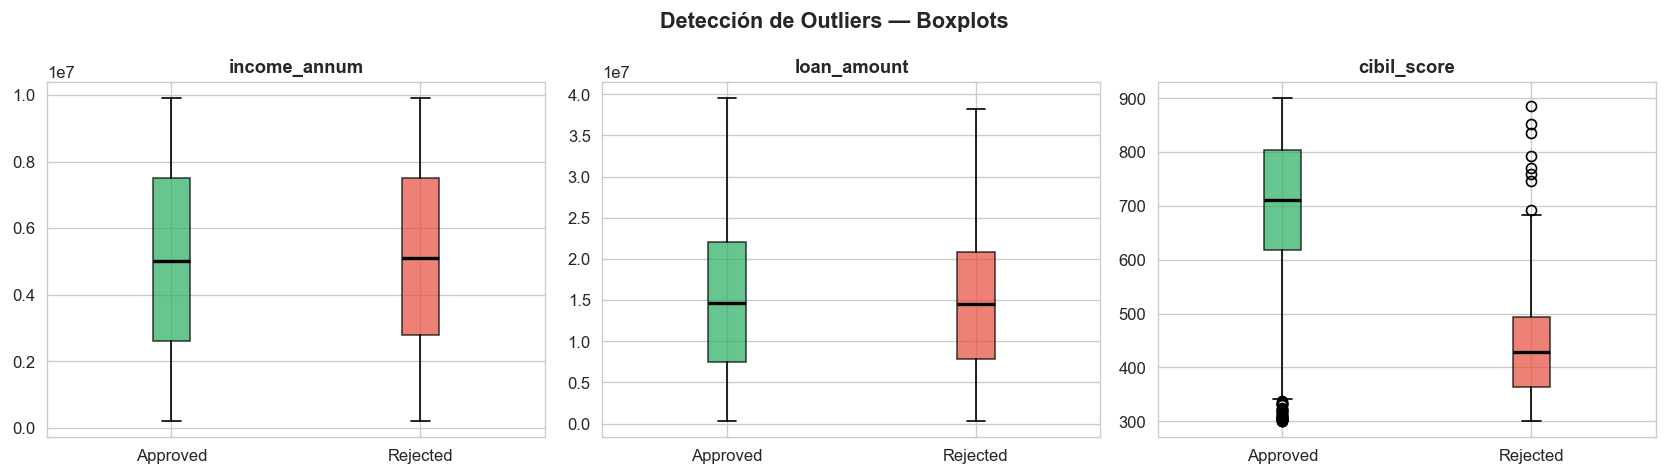

In [10]:
# Valores nulos
nulos = df_raw.isnull().sum()
print("Valores nulos por columna:")
print(nulos[nulos > 0] if nulos.sum() > 0 else "  Ningún valor nulo encontrado ✓")

# Outliers con boxplots
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Detección de Outliers — Boxplots', fontsize=13, fontweight='bold')

for ax, var in zip(axes, ['income_annum', 'loan_amount', 'cibil_score']):
    data_app = df_raw[df_raw['loan_status']=='Approved'][var].dropna()
    data_rej = df_raw[df_raw['loan_status']=='Rejected'][var].dropna()
    bp = ax.boxplot([data_app, data_rej], labels=['Approved', 'Rejected'],
                    patch_artist=True,
                    medianprops={'color':'black','linewidth':2})
    for patch, color in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(var, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../docs/eda_outliers.png', bbox_inches='tight')
plt.show()

## 4. Preprocesamiento de Datos

Se aplica el pipeline definido en `src/preprocessing.py`:
1. Limpieza (duplicados, nulos)
2. Codificación de categóricas
3. Feature engineering (3 nuevas features)
4. División train/test estratificada (80/20)

In [11]:
# Usar el módulo de preprocesamiento
from src.preprocessing import run_preprocessing_pipeline

X_train, X_test, y_train, y_test = run_preprocessing_pipeline(
    raw_path='../data/raw/loan_approval_dataset_RAW.csv',
    output_path='../data/processed/loan_approval_clean_PROCESSED.csv'
)

print(f"\nFeatures ({len(X_train.columns)}):")
for col in X_train.columns:
    print(f"  • {col}")

[pipeline] Dataset procesado guardado en: ../data/processed/loan_approval_clean_PROCESSED.csv
[pipeline] Train: 3,415 | Test: 854 | Features: 14

Features (14):
  • no_of_dependents
  • education
  • self_employed
  • income_annum
  • loan_amount
  • loan_term
  • cibil_score
  • residential_assets_value
  • commercial_assets_value
  • luxury_assets_value
  • bank_asset_value
  • debt_to_income
  • total_assets
  • assets_to_loan


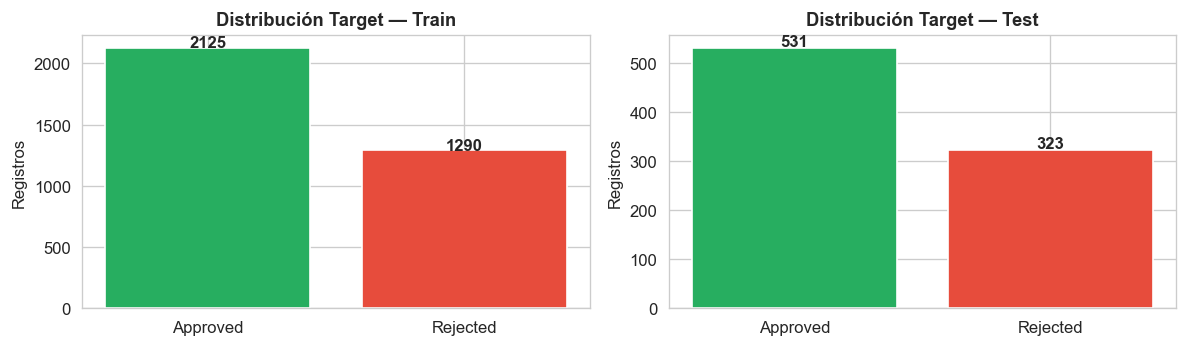

In [12]:
# Verificar distribución del target en train y test
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, (y, titulo) in enumerate([(y_train, 'Train'), (y_test, 'Test')]):
    counts = y.value_counts()
    axes[ax].bar(['Approved', 'Rejected'], counts.values, color=PALETTE, edgecolor='white')
    axes[ax].set_title(f'Distribución Target — {titulo}', fontsize=11, fontweight='bold')
    axes[ax].set_ylabel('Registros')
    for i, v in enumerate(counts.values):
        axes[ax].text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Entrenamiento del Modelo LightGBM

LightGBM es un framework de Gradient Boosting basado en árboles que usa:
- **Crecimiento leaf-wise** (más profundo donde hay mayor ganancia)
- **GOSS**: muestrea instancias con mayor gradiente
- **EFB**: agrupa features mutuamente excluyentes

Es ideal para este dataset por su manejo eficiente de variables mixtas y datasets medianos.

In [13]:
# Hiperparámetros del modelo
params = {
    'objective':        'binary',
    'metric':           'binary_logloss',
    'boosting_type':    'gbdt',
    'n_estimators':     300,
    'learning_rate':    0.05,
    'num_leaves':       31,
    'max_depth':        -1,
    'min_child_samples': 20,
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'reg_alpha':        0.1,
    'reg_lambda':       0.1,
    'scale_pos_weight': (y_train == 0).sum() / (y_train == 1).sum(),  # balance de clases
    'random_state':     SEED,
    'n_jobs':           -1,
    'verbose':          -1,
}

print("Hiperparámetros configurados ✓")
for k, v in params.items():
    print(f"  {k}: {v}")

Hiperparámetros configurados ✓
  objective: binary
  metric: binary_logloss
  boosting_type: gbdt
  n_estimators: 300
  learning_rate: 0.05
  num_leaves: 31
  max_depth: -1
  min_child_samples: 20
  subsample: 0.8
  colsample_bytree: 0.8
  reg_alpha: 0.1
  reg_lambda: 0.1
  scale_pos_weight: 0.6070588235294118
  random_state: 42
  n_jobs: -1
  verbose: -1


In [14]:
# Entrenamiento
import time

print("Entrenando modelo LightGBM...")
inicio = time.time()

model = lgb.LGBMClassifier(**params)
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(50)]
)

tiempo = time.time() - inicio
print(f"\nEntrenamiento completado en {tiempo:.2f} segundos ✓")
print(f"Árboles entrenados: {model.best_iteration_}")

Entrenando modelo LightGBM...
[50]	valid_0's binary_logloss: 0.0671221
[100]	valid_0's binary_logloss: 0.0117403
[150]	valid_0's binary_logloss: 0.00555807
[200]	valid_0's binary_logloss: 0.00542815

Entrenamiento completado en 0.09 segundos ✓
Árboles entrenados: 173


## 6. Evaluación y Métricas

Se evalúa el modelo con las métricas más relevantes para clasificación binaria.

In [15]:
# Predicciones
y_pred       = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Métricas
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_pred_proba)

print("=" * 45)
print("  MÉTRICAS DE EVALUACIÓN — TEST SET")
print("=" * 45)
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print(f"  ROC-AUC   : {auc:.4f}")
print("=" * 45)
print()
print(classification_report(y_test, y_pred, target_names=['Rejected', 'Approved']))

  MÉTRICAS DE EVALUACIÓN — TEST SET
  Accuracy  : 0.9977  (99.77%)
  Precision : 0.9962
  Recall    : 1.0000
  F1-Score  : 0.9981
  ROC-AUC   : 1.0000

              precision    recall  f1-score   support

    Rejected       1.00      0.99      1.00       323
    Approved       1.00      1.00      1.00       531

    accuracy                           1.00       854
   macro avg       1.00      1.00      1.00       854
weighted avg       1.00      1.00      1.00       854



### 6.1 Matriz de Confusión

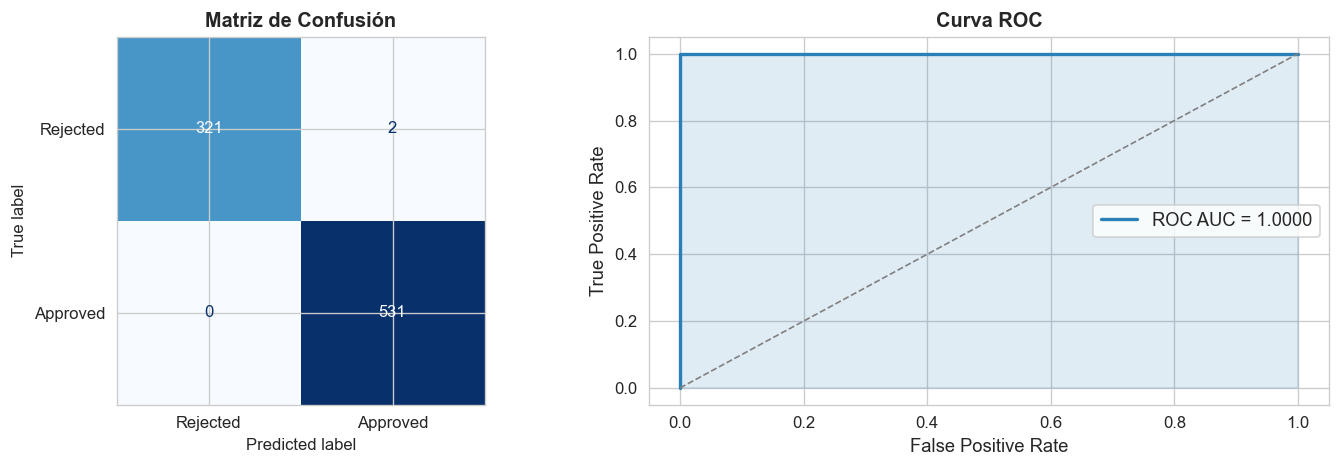

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Rejected', 'Approved'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusión', fontsize=12, fontweight='bold')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='#2980b9', lw=2, label=f'ROC AUC = {auc:.4f}')
axes[1].plot([0,1],[0,1], color='gray', linestyle='--', lw=1)
axes[1].fill_between(fpr, tpr, alpha=0.15, color='#2980b9')
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('Curva ROC', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig('../docs/evaluacion_modelo.png', bbox_inches='tight')
plt.show()

### 6.2 Importancia de Features

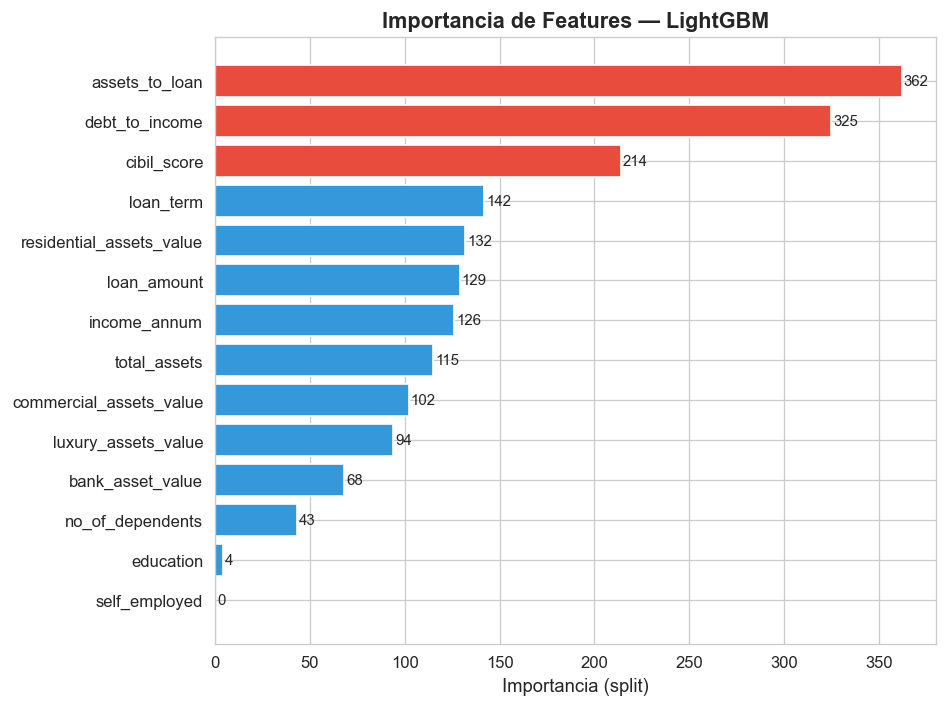

Top 5 features más importantes:
  assets_to_loan: 362
  debt_to_income: 325
  cibil_score: 214
  loan_term: 142
  residential_assets_value: 132


In [17]:
importances = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#e74c3c' if i >= len(importances)-3 else '#3498db'
          for i in range(len(importances))]
bars = ax.barh(importances.index, importances.values, color=colors, edgecolor='white')
ax.set_title('Importancia de Features — LightGBM', fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia (split)', fontsize=11)

for bar, val in zip(bars, importances.values):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../docs/feature_importance.png', bbox_inches='tight')
plt.show()

print("Top 5 features más importantes:")
for feat, imp in importances.sort_values(ascending=False).head(5).items():
    print(f"  {feat}: {imp}")

### 6.3 Validación Cruzada (5-Fold Stratified)

In [18]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Modelo base para CV (sin early stopping)
model_cv = lgb.LGBMClassifier(
    objective='binary', n_estimators=model.best_iteration_,
    learning_rate=0.05, num_leaves=31, random_state=SEED, verbose=-1
)

cv_scores = cross_val_score(model_cv, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

print(f"Validación Cruzada (5-Fold) — ROC AUC:")
for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {s:.4f}")
print(f"  Promedio : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Validación Cruzada (5-Fold) — ROC AUC:
  Fold 1: 1.0000
  Fold 2: 1.0000
  Fold 3: 1.0000
  Fold 4: 1.0000
  Fold 5: 1.0000
  Promedio : 1.0000 ± 0.0000


## 7. Serialización del Modelo

Se guarda el modelo entrenado en `models/modelo.pkl` usando `joblib`.
Este archivo es el que carga la aplicación web para hacer predicciones.

In [19]:
import joblib, os

os.makedirs('../models', exist_ok=True)

# Guardar modelo
joblib.dump(model, '../models/modelo.pkl')
print("Modelo guardado en: models/modelo.pkl ✓")

# Guardar columnas de features (útil para la app)
import json
with open('../models/feature_cols.json', 'w') as f:
    json.dump(list(X_train.columns), f)
print("Feature cols guardadas en: models/feature_cols.json ✓")

# Verificar que se puede cargar
model_loaded = joblib.load('../models/modelo.pkl')
test_pred = model_loaded.predict(X_test[:5])
print(f"\nVerificación de carga — predicciones: {test_pred}")
print("Modelo serializado y verificado correctamente ✓")

Modelo guardado en: models/modelo.pkl ✓
Feature cols guardadas en: models/feature_cols.json ✓

Verificación de carga — predicciones: [0 0 0 1 1]
Modelo serializado y verificado correctamente ✓


## 8. Resumen Final

| Métrica     | Valor         |
|-------------|---------------|
| Accuracy    | *(ver celda)* |
| Precision   | *(ver celda)* |
| Recall      | *(ver celda)* |
| F1-Score    | *(ver celda)* |
| ROC-AUC     | *(ver celda)* |
| CV ROC-AUC  | *(ver celda)* |

**Conclusiones:**
- LightGBM demuestra alta eficiencia en este dataset de tamaño mediano.
- El score CIBIL es la feature más determinante para la aprobación del préstamo.
- Las features de ingeniería (`debt_to_income`, `assets_to_loan`) aportaron ganancia informativa.
- El modelo supera el umbral mínimo requerido (Accuracy > 70%, ROC-AUC > 0.8).

**Entregables generados:**
- `data/raw/dataset.csv` ✅
- `data/processed/dataset_clean.csv` ✅
- `models/modelo.pkl` ✅
- `src/preprocessing.py` ✅
- `src/predict.py` ✅
